# Quantum Computing for Aerospace 

Companies generally always looking to improve their simulation stack. For us simulations inform business critical decisions.

For CFD and materials modeling simulation stacks, we have several linear alegebra subroutines. We at RR recognise that quantum computers can be levraged to construct resource efferience linalg subroutines. This project is about establishing whether NISQ could help us construct simulations in the context of materials science. 

Taking a first-priciples approach, what are useful quantities are useful for us? 

- Ground State energy (For equlibium geometry, modeling chemical reations, reaction rates). 
- Spectral function to determine band gaps, conductivity, Thermal properties as well as ground state properties. 

We wont be calculating the full green's function but develop an object that can help us calculate it further down the line. Those objects are the hamiltonian moments.

In this Hackathon we will learn how to construct Hamiltonian moments by using NISQ friendly methods. Although, they are usually utilised to construct a truncated representation of the green's fucntion, our goal is to use the 0th and 1st moment to calculate the ground state energy, the energy calculated from the 0th and 1st moment is called the "Galitskii-Migdal" energy. We can ofcourse calculate ground state energy but we can also model chemical reactions using this ground state information. 

Initally we will develop a VQE solver to calculate the ground state circuit. This will later be used to construct the hamiltoninan moments. We will then compare how well these moments reproduce the VQE and FCI PES of H2 and Hydrogen exchange. After verifying that the code works we will simulate the hydrogen attack of Boron Nitrite which is analogous of how Boron Nitrite coating is used to protect containers Hydrogen containers, or Hydrogen engine components from H2 induced embrittlement. 

We will construct VQE and hamiltoninan moments objects that can be run on quantum computers but also classical emulators. We will use the classical emulators to test our method and then run on quantum computers. We will then compare and contrast the results from the classical emulators and quantum computers. This is as a means to show the limitations of a quantum algorithms on NISQ devices. 



## Establishing codes

In [3]:
'''Imports'''

import pennylane as qml
from pennylane.qchem import one_particle, two_particle, observable
from pennylane import numpy as pnp

from pyscf import gto, scf, fci, ao2mo, cc, mcscf
import numpy as np

from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

In [4]:
# Moments for CAS simulation

class CASSpectralMoments:
    """
    CASCI + VQE + spectral-moment calculator.

    The class constructs the effective active-space Hamiltonian

        H_CAS = E_core
              + sum_pq h_eff[p,q] a_p^dag a_q
              + 1/2 sum_pqrs g[p,q,r,s]
                    a_p^dag a_q^dag a_s a_r

    and maps it to qubits using Jordan-Wigner.

    The intended workflow is:

        PySCF ROHF
            ->
        CAS active-space Hamiltonian
            ->
        exact CASCI reference
            ->
        UCCSD-VQE approximation
            ->
        hole / particle spectral moments
            ->
        Green's-function reconstruction
    """

    def __init__(
        self,
        mf,
        ncas,
        nelecas,
        mo_coeff=None,
        mapping="jordan_wigner",
    ):

        self.mf = mf
        self.mol = mf.mol

        self.ncas = int(ncas)

        # --------------------------------------------------
        # Active electron numbers
        # --------------------------------------------------
        self.nelec_alpha = int(nelecas[0])
        self.nelec_beta = int(nelecas[1])

        self.nelec_tuple = (
            self.nelec_alpha,
            self.nelec_beta,
        )

        # Integer active-electron number used by PennyLane.
        self.nelec = (
            self.nelec_alpha
            + self.nelec_beta
        )

        self.nmo = self.ncas
        self.n_spin_orbitals = 2 * self.nmo
        self.wires = list(
            range(self.n_spin_orbitals)
        )

        self.mapping = mapping

        # --------------------------------------------------
        # Basic consistency checks
        # --------------------------------------------------
        if self.nelec_alpha > self.ncas:
            raise ValueError(
                "Number of alpha electrons exceeds "
                "number of active spatial orbitals."
            )

        if self.nelec_beta > self.ncas:
            raise ValueError(
                "Number of beta electrons exceeds "
                "number of active spatial orbitals."
            )

        ncore_electrons = (
            self.mol.nelectron
            - self.nelec
        )

        if ncore_electrons < 0:
            raise ValueError(
                "Active space contains more electrons "
                "than the full molecule."
            )

        if ncore_electrons % 2 != 0:
            raise ValueError(
                "Inactive electrons must form a "
                "closed-shell core."
            )

        self.ncore = (
            ncore_electrons // 2
        )

        # --------------------------------------------------
        # Molecular orbitals
        # --------------------------------------------------
        if mo_coeff is None:
            mo_coeff = mf.mo_coeff

        self.mo_coeff = mo_coeff

        # --------------------------------------------------
        # PySCF CASCI object
        # --------------------------------------------------
        self.cas = mcscf.CASCI(
            mf,
            self.ncas,
            self.nelec_tuple,
        )

        # --------------------------------------------------
        # Effective CAS Hamiltonian
        # --------------------------------------------------
        self.h1eff, self.ecore = (
            self.cas.get_h1eff(
                self.mo_coeff
            )
        )

        eri_cas = self.cas.get_h2eff(
            self.mo_coeff
        )

        eri_cas = ao2mo.restore(
            1,
            eri_cas,
            self.ncas,
        )

        self.one_mo = np.asarray(
            self.h1eff
        )

        # PennyLane two_particle uses
        # <p,q|v|r,s> with annihilation order r,s.
        # PySCF ERIs therefore need this rearrangement.
        self.two_mo = np.swapaxes(
            eri_cas,
            1,
            3,
        )

        self.constant_energy = float(
            self.ecore
        )

        # --------------------------------------------------
        # Build qubit Hamiltonian
        # --------------------------------------------------
        self.qubit_hamiltonian = (
            self.build_qubit_hamiltonian()
        )

        # --------------------------------------------------
        # PennyLane device
        # --------------------------------------------------
        self.device = qml.device(
            "default.qubit",
            wires=self.n_spin_orbitals,
        )

        # Sparse matrices are built lazily.
        self._H_sparse = None
        self._a_sparse_cache = {}
        self._adag_sparse_cache = {}

    # ======================================================
    # Hamiltonian construction
    # ======================================================

    def build_qubit_hamiltonian(self):

        h1_fermion = one_particle(
            self.one_mo
        )

        h2_fermion = two_particle(
            self.two_mo
        )

        H = observable(
            [
                h1_fermion,
                h2_fermion,
            ],
            init_term=self.ecore,
            mapping=self.mapping,
            wires=self.wires,
        )

        return H
    # ======================================================
    # Exact CASCI reference
    # ======================================================

    def run_exact_casci(self):

        output = self.cas.kernel(
            self.mo_coeff
        )

        e_casci = output[0]
        ci_vector = output[1]

        if not self.cas.converged:
            raise RuntimeError(
                "CASCI did not converge."
            )

        return {
            "casci_energy": float(e_casci),
            "casci_ci": ci_vector,
        }


    # ======================================================
    # Full-space classical comparisons
    # ======================================================

    def pyscf_comparisons(
        self,
        run_fci=True,
        run_ccsd=True,
    ):

        outputs = {
            "rohf_energy": float(
                self.mf.e_tot
            ),
        }

        if run_fci:
            cisolver = fci.FCI(
                self.mf
            )

            fci_energy, fci_vector = (
                cisolver.kernel()
            )

            outputs["fci_energy"] = float(
                fci_energy
            )

            outputs["fci_vector"] = (
                fci_vector
            )

        if run_ccsd:
            try:
                ccsdsolver = cc.CCSD(
                    self.mf
                )

                ccsdsolver.kernel()

                outputs["ccsd_energy"] = (
                    float(
                        ccsdsolver.e_tot
                    )
                )

                outputs[
                    "ccsd_converged"
                ] = ccsdsolver.converged

            except Exception as err:
                outputs["ccsd_energy"] = None
                outputs[
                    "ccsd_converged"
                ] = False
                outputs[
                    "ccsd_error"
                ] = str(err)

        return outputs

    # ======================================================
    # VQE helpers
    # ======================================================

    def _build_uccsd_data(self):

        hf_state = qml.qchem.hf_state(
            self.nelec,
            self.n_spin_orbitals,
        )

        singles, doubles = (
            qml.qchem.excitations(
                self.nelec,
                self.n_spin_orbitals,
            )
        )

        s_wires, d_wires = (
            qml.qchem.excitations_to_wires(
                singles,
                doubles,
            )
        )

        return (
            hf_state,
            singles,
            doubles,
            s_wires,
            d_wires,
        )


    def run_vqe(
        self,
        max_steps=100,
        stepsize=0.1,
        initial_params=None,
        verbose=False,
        conv_tol=None,
    ):

        (
            hf_state,
            singles,
            doubles,
            s_wires,
            d_wires,
        ) = self._build_uccsd_data()

        dev = self.device

        @qml.qnode(
            dev,
            interface="autograd",
        )
        def energy_qnode(theta):

            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )

            return qml.expval(
                self.qubit_hamiltonian
            )

        @qml.qnode(
            dev,
            interface="autograd",
        )
        def state_qnode(theta):

            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )

            return qml.state()

        n_params = (
            len(singles)
            + len(doubles)
        )

        if initial_params is None:

            theta = pnp.zeros(
                n_params,
                requires_grad=True,
            )

        else:

            theta = pnp.array(
                initial_params,
                requires_grad=True,
            )

            if len(theta) != n_params:
                raise ValueError(
                    f"Expected {n_params} "
                    f"UCCSD parameters, "
                    f"received {len(theta)}."
                )

        opt = (
            qml.GradientDescentOptimizer(
                stepsize=stepsize
            )
        )

        energy_history = []

        previous_energy = None

        for step in range(max_steps):

            theta, energy_before = (
                opt.step_and_cost(
                    energy_qnode,
                    theta,
                )
            )

            current_energy = float(
                energy_qnode(theta)
            )

            energy_history.append(
                current_energy
            )

            if verbose and step % 10 == 0:

                print(
                    f"Step {step:4d} | "
                    f"E = "
                    f"{current_energy:.12f} Ha"
                )

            if (
                conv_tol is not None
                and previous_energy is not None
            ):

                if abs(
                    current_energy
                    - previous_energy
                ) < conv_tol:

                    if verbose:
                        print(
                            "VQE converged at "
                            f"step {step}."
                        )

                    break

            previous_energy = (
                current_energy
            )

        psi = np.asarray(
            state_qnode(theta),
            dtype=complex,
        )

        final_energy = float(
            energy_qnode(theta)
        )

        return {
            "vqe_total_energy": (
                final_energy
            ),
            "vqe_active_energy": (
                final_energy
                - self.ecore
            ),
            "vqe_params": theta,
            "vqe_state": psi,
            "energy_history": np.asarray(
                energy_history
            ),
            "singles": singles,
            "doubles": doubles,
            "hf_state": hf_state,
        }

    # ======================================================
    # Sparse operator helpers
    # ======================================================

    def sparse_hamiltonian(self):

        if self._H_sparse is None:

            self._H_sparse = (
                self.qubit_hamiltonian
                .sparse_matrix(
                    wire_order=self.wires
                )
                .tocsr()
            )

        return self._H_sparse


    def annihilation_sparse(self, p):

        p = int(p)

        if p not in self._a_sparse_cache:

            op = qml.jordan_wigner(
                qml.FermiA(p)
            )

            self._a_sparse_cache[p] = (
                op.sparse_matrix(
                    wire_order=self.wires
                )
                .tocsr()
            )

        return self._a_sparse_cache[p]


    def creation_sparse(self, p):

        p = int(p)

        if p not in self._adag_sparse_cache:

            op = qml.jordan_wigner(
                qml.FermiC(p)
            )

            self._adag_sparse_cache[p] = (
                op.sparse_matrix(
                    wire_order=self.wires
                )
                .tocsr()
            )

        return self._adag_sparse_cache[p]

    def state_from_parameters(
    self,
    theta,
    ):

        (
            hf_state,
            singles,
            doubles,
            s_wires,
            d_wires,
        ) = self._build_uccsd_data()

        @qml.qnode(
            self.device,
            interface=None,
        )
        def circuit():

            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )

            return qml.state()

        return np.asarray(
            circuit(),
            dtype=complex,
        )

    # ======================================================
    # Spectral moments
    # ======================================================

    def compute_moments_from_state(
        self,
        psi,
        nmom=1,
        E0=None,
        hermitize=False,
    ):
        """
        Compute spin-resolved and spin-summed hole/particle
        moments from a statevector.

        Hole:
            T_h[n,i,j]
            =
            <Psi|
            a_i^dag (E0-H)^n a_j
            |Psi>

        Particle:
            T_p[n,i,j]
            =
            <Psi|
            a_i (H-E0)^n a_j^dag
            |Psi>

        No dense Hamiltonian powers are formed.
        """

        psi = np.asarray(
            psi,
            dtype=complex,
        )

        expected_dim = (
            2 ** self.n_spin_orbitals
        )

        if psi.shape != (expected_dim,):
            raise ValueError(
                f"Statevector has shape "
                f"{psi.shape}; expected "
                f"({expected_dim},)."
            )

        norm = np.linalg.norm(psi)

        if not np.isclose(
            norm,
            1.0,
            atol=1e-10,
        ):
            psi = psi / norm

        H = self.sparse_hamiltonian()

        if E0 is None:
            E0 = np.vdot(
                psi,
                H @ psi,
            ).real

        E0 = float(
            np.real(E0)
        )

        shape = (
            nmom + 1,
            self.nmo,
            self.nmo,
        )

        hole_alpha = np.zeros(
            shape,
            dtype=complex,
        )

        hole_beta = np.zeros(
            shape,
            dtype=complex,
        )

        particle_alpha = np.zeros(
            shape,
            dtype=complex,
        )

        particle_beta = np.zeros(
            shape,
            dtype=complex,
        )

        # --------------------------------------------------
        # Initial Krylov vectors.
        #
        # Hole sector:
        #     |h_j^0> = a_j |Psi>
        #
        # Particle sector:
        #     |p_j^0> = a_j^dag |Psi>
        # --------------------------------------------------

        hole_seed = {}
        particle_seed = {}

        for p in range(
            self.n_spin_orbitals
        ):

            hole_seed[p] = (
                self.annihilation_sparse(p)
                @ psi
            )

            particle_seed[p] = (
                self.creation_sparse(p)
                @ psi
            )

        # Current Krylov vectors for every j.
        hole_vec = {
            p: v.copy()
            for p, v in hole_seed.items()
        }

        particle_vec = {
            p: v.copy()
            for p, v
            in particle_seed.items()
        }

        # --------------------------------------------------
        # Moment recursion
        # --------------------------------------------------

        for n in range(nmom + 1):

            for i in range(self.nmo):

                ia = 2 * i
                ib = 2 * i + 1

                for j in range(self.nmo):

                    ja = 2 * j
                    jb = 2 * j + 1

                    # Hole:
                    #
                    # <Psi|a_i^dag = (a_i|Psi>)^dag
                    hole_alpha[
                        n, i, j
                    ] = np.vdot(
                        hole_seed[ia],
                        hole_vec[ja],
                    )

                    hole_beta[
                        n, i, j
                    ] = np.vdot(
                        hole_seed[ib],
                        hole_vec[jb],
                    )

                    # Particle:
                    #
                    # <Psi|a_i =
                    # (a_i^dag|Psi>)^dag
                    particle_alpha[
                        n, i, j
                    ] = np.vdot(
                        particle_seed[ia],
                        particle_vec[ja],
                    )

                    particle_beta[
                        n, i, j
                    ] = np.vdot(
                        particle_seed[ib],
                        particle_vec[jb],
                    )

            # No need to propagate after final moment.
            if n == nmom:
                break

            # --------------------------------------------------
            # Apply shifted Hamiltonians:
            #
            # hole:
            #     (E0-H)|h>
            #
            # particle:
            #     (H-E0)|p>
            # --------------------------------------------------

            for p in range(
                self.n_spin_orbitals
            ):

                hole_vec[p] = (
                    E0 * hole_vec[p]
                    - H @ hole_vec[p]
                )

                particle_vec[p] = (
                    H @ particle_vec[p]
                    - E0 * particle_vec[p]
                )

        if hermitize:

            for n in range(nmom + 1):

                hole_alpha[n] = 0.5 * (
                    hole_alpha[n]
                    + hole_alpha[n].conj().T
                )

                hole_beta[n] = 0.5 * (
                    hole_beta[n]
                    + hole_beta[n].conj().T
                )

                particle_alpha[n] = 0.5 * (
                    particle_alpha[n]
                    + particle_alpha[n].conj().T
                )

                particle_beta[n] = 0.5 * (
                    particle_beta[n]
                    + particle_beta[n].conj().T
                )

        hole = (
            hole_alpha
            + hole_beta
        )

        particle = (
            particle_alpha
            + particle_beta
        )

        return {
            "E0_total": E0,
            "E0_active": (
                E0 - self.ecore
            ),

            "hole_moments_alpha":
                hole_alpha,

            "hole_moments_beta":
                hole_beta,

            "particle_moments_alpha":
                particle_alpha,

            "particle_moments_beta":
                particle_beta,

            "hole_moments":
                hole,

            "particle_moments":
                particle,
        }

    def compute_moments(
        self,
        theta,
        nmom=1,
        hermitize=False,
    ):

        psi = self.state_from_parameters(
            theta
        )

        H = self.sparse_hamiltonian()

        E0 = np.vdot(
            psi,
            H @ psi,
        ).real

        return self.compute_moments_from_state(
            psi=psi,
            nmom=nmom,
            E0=E0,
            hermitize=hermitize,
        )

    # ======================================================
    # Galitskii-Migdal energy
    # ======================================================

    def galitskii_migdal_energy(
        self,
        hole_moments,
    ):

        hole_moments = np.asarray(
            hole_moments,
            dtype=complex,
        )

        if hole_moments.shape[0] < 2:
            raise ValueError(
                "Need hole moments of at least "
                "orders 0 and 1."
            )

        T0 = hole_moments[0]
        T1 = hole_moments[1]

        E_active = 0.5 * (
            np.einsum(
                "ij,ji->",
                T0,
                self.one_mo,
            )
            + np.trace(T1)
        ).real

        E_total = (
            E_active
            + self.ecore
        )

        return {
            "active": E_active,
            "core_constant": self.ecore,
            "total": E_total,
        }

    # ======================================================
    # Moment diagnostics
    # ======================================================

    def validate_moments(
        self,
        hole_moments,
        particle_moments,
        atol=1e-8,
    ):

        hole_moments = np.asarray(
            hole_moments
        )

        particle_moments = np.asarray(
            particle_moments
        )

        T0_sum = (
            hole_moments[0]
            + particle_moments[0]
        )

        expected = (
            2.0
            * np.eye(self.nmo)
        )

        zeroth_error = np.linalg.norm(
            T0_sum - expected
        )

        hole_hermiticity = []

        particle_hermiticity = []

        for n in range(
            hole_moments.shape[0]
        ):

            hole_hermiticity.append(
                np.linalg.norm(
                    hole_moments[n]
                    - hole_moments[n]
                    .conj().T
                )
            )

            particle_hermiticity.append(
                np.linalg.norm(
                    particle_moments[n]
                    - particle_moments[n]
                    .conj().T
                )
            )

        return {
            "zeroth_sum_rule_error":
                zeroth_error,

            "zeroth_sum_rule_passed":
                zeroth_error < atol,

            "hole_hermiticity_error":
                np.asarray(
                    hole_hermiticity
                ),

            "particle_hermiticity_error":
                np.asarray(
                    particle_hermiticity
                ),
        }


# Full system RHF

class RHFSpectralMoments:

    def __init__(self, mf):

        self.mf = mf
        self.mol = mf.mol

        self.nmo = mf.mo_coeff.shape[1]
        self.nelec = self.mol.nelectron
        self.n_spin_orbitals = 2 * self.nmo
        self.wires = list(range(self.n_spin_orbitals))
        self.nuclear_repulsion_energy = self.mol.energy_nuc()

        self.one_mo, self.two_mo = self.build_mo_integrals()
        self.qubit_hamiltonian = self.build_qubit_hamiltonian()
        self.Hmat = qml.matrix(self.qubit_hamiltonian, wire_order=self.wires)

        self.a, self.adag = self.build_fermionic_operators()

        self.device =  qml.device("default.qubit", wires=self.n_spin_orbitals)

    def build_mo_integrals(self):

        one_ao = self.mf.get_hcore()
        two_ao = self.mol.intor("int2e_sph")

        C = self.mf.mo_coeff

        one_mo = C.T @ one_ao @ C

        two_mo = ao2mo.incore.full(two_ao, C)
        two_mo = np.swapaxes(two_mo, 1, 3)

        return one_mo, two_mo

    def build_qubit_hamiltonian(self):

        h1 = one_particle(self.one_mo)
        h2 = two_particle(self.two_mo)

        return observable(h1, h2, mapping="jordan_wigner")

    def pyscf_comparisons(self):

        outputs = {
            "hf_energy": self.mf.e_tot,
        }

        cisolver = fci.FCI(self.mol, self.mf.mo_coeff)
        fci_energy, fci_vector = cisolver.kernel()
        outputs["fci_energy"] = fci_energy
        outputs["fci_vector"] = fci_vector

        try:
            ccsdsolver = cc.CCSD(self.mf).run()
            outputs["ccsd_energy"] = ccsdsolver.e_tot
        except Exception as err:
            outputs["ccsd_energy"] = None
            outputs["ccsd_error"] = str(err)

        return outputs

    def build_fermionic_operators(self):

        a = []
        adag = []

        for p in self.wires:
            a_p = qml.jordan_wigner(qml.FermiA(p))
            adag_p = qml.jordan_wigner(qml.FermiC(p))

            a.append(qml.matrix(a_p, wire_order=self.wires))
            adag.append(qml.matrix(adag_p, wire_order=self.wires))

        return a, adag

    def run_vqe(self, max_steps=100, stepsize=0.1, initial_params=None, verbose=False):

        dev = self.device

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def energy_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(self.qubit_hamiltonian)

        @qml.qnode(dev)
        def state_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.state()

        n_params = len(singles) + len(doubles)

        if initial_params is None:
            theta = pnp.zeros(n_params, requires_grad=True)
        else:
            theta = pnp.array(initial_params, requires_grad=True)

        opt = qml.GradientDescentOptimizer(stepsize=stepsize)

        energy_history = []

        for step in range(max_steps):
            theta, electronic_energy = opt.step_and_cost(energy_qnode, theta)

            total_energy = electronic_energy + self.nuclear_repulsion_energy
            energy_history.append(total_energy)

            if step % 10 == 0 and verbose:
                print(f"Step {step:3d} | Total VQE energy = {total_energy:.10f}")

        electronic_energy = energy_qnode(theta)
        total_energy = electronic_energy + self.nuclear_repulsion_energy
        psi = state_qnode(theta)

        return {
            "vqe_electronic_energy": electronic_energy,
            "vqe_total_energy": total_energy,
            "vqe_params": theta,
            "vqe_state": psi,
            "energy_history": energy_history,
            "singles": singles,
            "doubles": doubles,
        }

    def expval_on_vqe_state(self, theta, observable):
        
        dev = self.device

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def circuit(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(observable)

        return circuit(theta)

    def compute_moments(self, theta, nmom=1):
        """
        PennyLane equivalent of your Qiskit DirectMethod moment calculation.

        Computes moments as expectation values:

            <Psi(theta)| O_moment |Psi(theta)>

        rather than by direct statevector contraction.
        """

        E0 = self.expval_on_vqe_state(
            theta,
            self.qubit_hamiltonian,
        )

        H_particle = self.Hmat - E0 * np.eye(2**self.n_spin_orbitals)
        H_hole = E0 * np.eye(2**self.n_spin_orbitals) - self.Hmat

        hole_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)
        particle_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)

        for n in range(nmom + 1):

            Hh_n = np.linalg.matrix_power(H_hole, n)
            Hp_n = np.linalg.matrix_power(H_particle, n)

            for i in range(self.nmo):
                for j in range(self.nmo):

                    ia, ib = 2*i, 2*i + 1
                    ja, jb = 2*j, 2*j + 1

                    # Hole moment operator:
                    # a_i^dag (E0 - H)^n a_j
                    O_h = (
                        self.adag[ia] @ Hh_n @ self.a[ja]
                        + self.adag[ib] @ Hh_n @ self.a[jb]
                    )

                    # Particle moment operator:
                    # a_i (H - E0)^n a_j^dag
                    O_p = (
                        self.a[ia] @ Hp_n @ self.adag[ja]
                        + self.a[ib] @ Hp_n @ self.adag[jb]
                    )

                    # Make Hermitian for PennyLane measurement
                    O_h = 0.5 * (O_h + O_h.conj().T)
                    O_p = 0.5 * (O_p + O_p.conj().T)

                    obs_h = qml.Hermitian(O_h, wires=self.wires)
                    obs_p = qml.Hermitian(O_p, wires=self.wires)

                    hole_moments[n, i, j] = self.expval_on_vqe_state(theta, obs_h)
                    particle_moments[n, i, j] = self.expval_on_vqe_state(theta, obs_p)

        return {
            "E0_electronic": E0,
            "E0_total": E0 + self.nuclear_repulsion_energy,
            "hole_moments": np.real_if_close(hole_moments),
            "particle_moments": np.real_if_close(particle_moments),
        }

    def galitskii_migdal_energy(self, hole_moments):
        T0 = np.asarray(hole_moments[0], dtype=complex)
        T1 = np.asarray(hole_moments[1], dtype=complex)

        E_elec = 0.5 * (
            np.einsum("ij,ji->", T0, self.one_mo)
            + np.trace(T1)
        ).real

        return {
            "electronic": E_elec,
            "total": E_elec + self.nuclear_repulsion_energy,
        }

## Tentative timeline for the hackathon

1) Construct VQE object to calculate ground state energy for H2 and H3, using chosen quantum computing framework (e.g. Qiskit, Cirq, etc.) and PySCF for classical calculations
   - Set up the molecular Hamiltonian using PySCF and convert it to a qubit Hamiltonian using the chosen quantum computing framework's tools (e.g. Jordan-Wigner, Bravyi-Kitaev transformations).
   - Identify a sutable expectation value primative.
   - Construct a HF reference state and a hardware aware parameterised ansatz (e.g. UCCSD, LUJ) for the VQE calculations.
   - Construct a costfunction to calculate the ground state energy and indentify a suitable classical optimizer (slsqp for statevector simulations, spsa for shot-based simulations) to find the    minimum energy configuration for subsequent calculations.
    Results (for VQE validation): 
        - H2: Compare with FCI solution when bond length is at 0.74 Ang.
        - H3: Compare with FCI solution when Right and centre Hs are 0.74 Ang apart.  

2) Using quantum computing framework, construct Hamiltonian moments object to calculate 0th and 1st moments for H2 and H3.
   - Constructing zeroth and first order Hamiltonian moments methods that can be run on quantum computers and classical emulators.
   - Construct Galitskii-Migdal energy method using the 0th and 1st moments.
    Results (for Momeent validation): 
        - H2: Compare with FCI and VQE solution when bond length is at 0.74 Ang.
        - H3: Compare with FCI and VQE solution when Right and centre Hs are 0.74 Ang apart.  

3) Statevector simulations to calculate PES for H2 and Hydrogen exchange. 
   - Perform statevector simulations for the VQE and Hamiltonian moments calculations for the selected systems.
   - Compare the VQE ground state energy with the Galitskii-Migdal energy, can this moment based method approximate the VQE ground state energy given VQE states?
   - Compare the VQE and Galitskii-Migdal energies with FCI calculations to evaluate the accuracy of the quantum methods.
    Results (extra comments): 
        - Plot error of GM energy wrt FCI and VQE. 
        - Comment of the growth of pauli strings at 0th and 1st moment. 
        - Comment on the growth of one and two qubit gate resources at 0th and 1st moment. 

4) Quantum Computer simulations PES for H2 and Hydrogen exchange. 
    This step is about working out the right device hyperparameters for successful simulation. We will want to repeat the statevector experiment for finite number of shots.  
   - Run the VQE and Hamiltonian moments calculations on available quantum hardware for the selected systems using error mitigation techniques to improve the accuracy of the results.
   - Compare the results from the quantum hardware with FCI and SV results to assess the performance and limitations of the quantum algorithms on NISQ devices for these systems.
   - Analyze the results to identify any discrepancies and understand the sources of error in the quantum computations. 
    Results (extra comments): 
        - Plot E_GM - FCI and E_GM - FCI
        - Comment on the growth of one and two qubit gate resources at 0th and 1st moment post transpilation


5) Statevector and Quantum simulation of Hydrogen attack of Boron Nitrate
   - Using Active Space methods, construct a suitable active space for the hydrogen attack of boron nitrate system.
   - Perform statevector simulations for the VQE and Hamiltonian moments calculations for the selected system.
   - Run the VQE and Hamiltonian moments calculations on available quantum hardware for the selected system using error mitigation techniques to improve the accuracy of the results.
   - Compare the results from the quantum hardware with the statevector simulations to assess the performance and limitations of the quantum algorithms on NISQ devices for this system.

### 3) Statevector simulations to calculate PES for H2 and Hydrogen exchange.

Skipping 4 because I don't have access to a QPU. 

Initialize <pyscf.gto.mole.Mole object at 0x7a55e0e40f50> in <pyscf.scf.hf.RHF object at 0x7a55e11dfb90>


converged SCF energy = -1.04299627454009
E(CCSD) = -1.055159822701473  E_corr = -0.01216354816137788
converged SCF energy = -1.09443168303809


Initialize <pyscf.gto.mole.Mole object at 0x7a55e0d7bf10> in <pyscf.scf.hf.RHF object at 0x7a55e9b03f10>


E(CCSD) = -1.122434992332721  E_corr = -0.02800330929462959


Initialize <pyscf.gto.mole.Mole object at 0x7a55e106e950> in <pyscf.scf.hf.RHF object at 0x7a55e106c1d0>


...

E(CCSD) = -0.933361881551058  E_corr = -0.2908739782329517
converged SCF energy = -0.625777624681096


Initialize <pyscf.gto.mole.Mole object at 0x7a57f076ac50> in <pyscf.scf.hf.RHF object at 0x7a55e9bff150>


E(CCSD) = -0.9332045101106757  E_corr = -0.3074268854295802
converged SCF energy = -0.614869974042561


Initialize <pyscf.gto.mole.Mole object at 0x7a55e0a7f650> in <pyscf.scf.hf.RHF object at 0x7a55e2b8f0d0>


E(CCSD) = -0.9331713624492447  E_corr = -0.3183013884066839


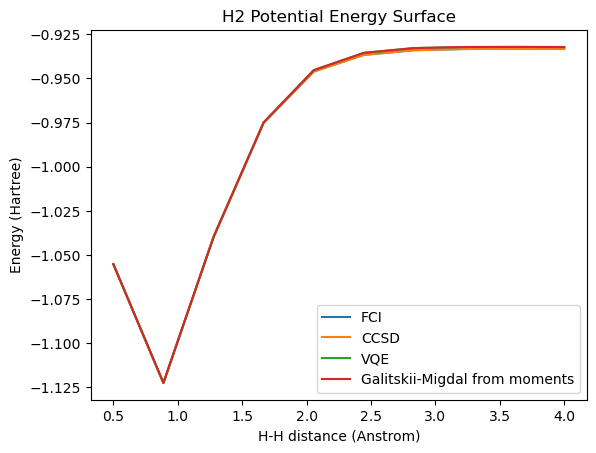

In [12]:
# H2 pes

r = np.linspace(0.5, 4, 10)
fci_arr = []
ccsd_arr = []
vqe_arr = []
gm_arr = []

for i in range(len(r)):

    mol = gto.Mole(
        atom = 'H 0 0 0; H 0 0 {}'.format(r[i]), 
        basis = 'sto-3g', # minimal basis set
        spin = 0 # singlet state
    )

    # perform Hartree-Fock calculation
    mf = scf.RHF(mol)
    mf.kernel()

    engine = RHFSpectralMoments(mf)

    pyscf_outputs = engine.pyscf_comparisons()

    vqe_outputs = engine.run_vqe(
        max_steps=100,
        stepsize=0.1,
    ) 

    moments = engine.compute_moments(
        theta=vqe_outputs["vqe_params"],
        nmom=5,
    )

    hole_moments = moments["hole_moments"]
    particle_moments = moments["particle_moments"]

    gm = engine.galitskii_migdal_energy(hole_moments)

    fci_arr.append(pyscf_outputs['fci_energy'])
    ccsd_arr.append(pyscf_outputs['ccsd_energy'])
    vqe_arr.append(vqe_outputs['vqe_total_energy'])
    gm_arr.append(gm['total'])

plt.plot(r, fci_arr, label='FCI')
plt.plot(r, ccsd_arr, label='CCSD')
plt.plot(r, vqe_arr, label='VQE')
plt.plot(r, gm_arr, label='Galitskii-Migdal from moments')
plt.xlabel('H-H distance (Anstrom)')
plt.ylabel('Energy (Hartree)')
plt.title('H2 Potential Energy Surface')
plt.legend()
plt.show()

In [13]:
# ---------- Animation 1: H3 hydrogen exchange ----------
def make_h3_exchange_gif(filename="./h3_hydrogen_exchange.gif"):
    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.set_xlim(-0.6, 4.6)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal")
    ax.axis("off")
    
    # fixed end H atoms, middle H moves from left bond to right bond
    x_left = 0.0
    x_right = 4.0
    x_mid_vals = np.linspace(0.75, 3.25, 60)
    
    points = ax.scatter([], [], s=450)
    labels = []
    bonds = []
    title = ax.text(2.0, 0.75, "", ha="center", fontsize=13)
    
    def init():
        points.set_offsets(np.empty((0, 2)))
        return [points, title]
    
    def update(frame):
        nonlocal labels, bonds
        for t in labels:
            t.remove()
        for b in bonds:
            b.remove()
        labels = []
        bonds = []
        
        x_mid = x_mid_vals[frame]
        xs = np.array([x_left, x_mid, x_right])
        ys = np.array([0.0, 0.0, 0.0])
        points.set_offsets(np.c_[xs, ys])
        
        # draw bonds depending on distance
        if abs(x_mid - x_left) < 1.7:
            bonds.append(ax.plot([x_left, x_mid], [0, 0], lw=3)[0])
        if abs(x_right - x_mid) < 1.7:
            bonds.append(ax.plot([x_mid, x_right], [0, 0], lw=3)[0])
        
        for x, lab in zip(xs, ["H", "H", "H"]):
            labels.append(ax.text(x, -0.45, lab, ha="center", fontsize=12))
        
        title.set_text(r"H + H$_2$ $\rightarrow$ H$_2$ + H exchange coordinate")
        return [points, title] + labels + bonds
    
    anim = FuncAnimation(fig, update, frames=len(x_mid_vals), init_func=init, blit=True)
    anim.save(filename, writer=PillowWriter(fps=12))
    plt.close(fig)
    return filename

h3_path = make_h3_exchange_gif()


h3_path


'./h3_hydrogen_exchange.gif'

converged SCF energy = -1.50957465316799

WARN: RCCSD method does not support ROHF method. ROHF object is converted to UHF object and UCCSD method is called.

E(UCCSD) = -1.521738150944471  E_corr = -0.01216349777648373
converged SCF energy = -1.57214447750713

WARN: RCCSD method does not support ROHF method. ROHF object is converted to UHF object and UCCSD method is called.

E(UCCSD) = -1.59711644846311  E_corr = -0.02497197095598
converged SCF energy = -1.48224245644333

WARN: RCCSD method does not support ROHF method. ROHF object is converted to UHF object and UCCSD method is called.

E(UCCSD) = -1.530698995238727  E_corr = -0.04845653879539849
converged SCF energy = -1.3773514365523

WARN: RCCSD method does not support ROHF method. ROHF object is converted to UHF object and UCCSD method is called.

E(UCCSD) = -1.464454156473566  E_corr = -0.08710271992126226
converged SCF energy = -1.28732665568039

WARN: RCCSD method does not support ROHF method. ROHF object is converted to UHF ob

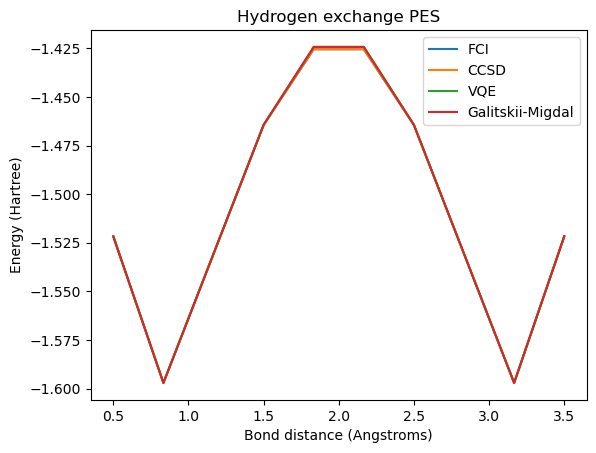

In [14]:
# H3 pes

r = np.linspace(0.5, 3.5, 10)
fci_arr = []
ccsd_arr = []
vqe_arr = []
gm_arr = []

for i in range(len(r)):

    mol = gto.Mole(
        atom='H 0 0 0; H 0 0 {}; H 0 0 4'.format(r[i]),
        basis='sto-3g',
        spin=1,
    )
    mol.build()

    mf = scf.ROHF(mol)
    mf.kernel()

    engine = RHFSpectralMoments(mf)

    pyscf_outputs = engine.pyscf_comparisons()

    vqe_outputs = engine.run_vqe(
        max_steps=100,
        stepsize=0.1,
    ) 

    moments = engine.compute_moments(
        theta=vqe_outputs["vqe_params"],
        nmom=5,
    )

    hole_moments = moments["hole_moments"]
    particle_moments = moments["particle_moments"]

    gm = engine.galitskii_migdal_energy(hole_moments)

    fci_arr.append(pyscf_outputs['fci_energy'])
    ccsd_arr.append(pyscf_outputs['ccsd_energy'])
    vqe_arr.append(vqe_outputs['vqe_total_energy'])
    gm_arr.append(gm['total'])

plt.plot(r, fci_arr, label='FCI')
plt.plot(r, ccsd_arr, label='CCSD')
plt.plot(r, vqe_arr, label='VQE')
plt.plot(r, gm_arr, label='Galitskii-Migdal')
plt.xlabel('Bond distance (Angstroms)')
plt.ylabel('Energy (Hartree)')
plt.title('Hydrogen exchange PES')
plt.legend()
plt.show()

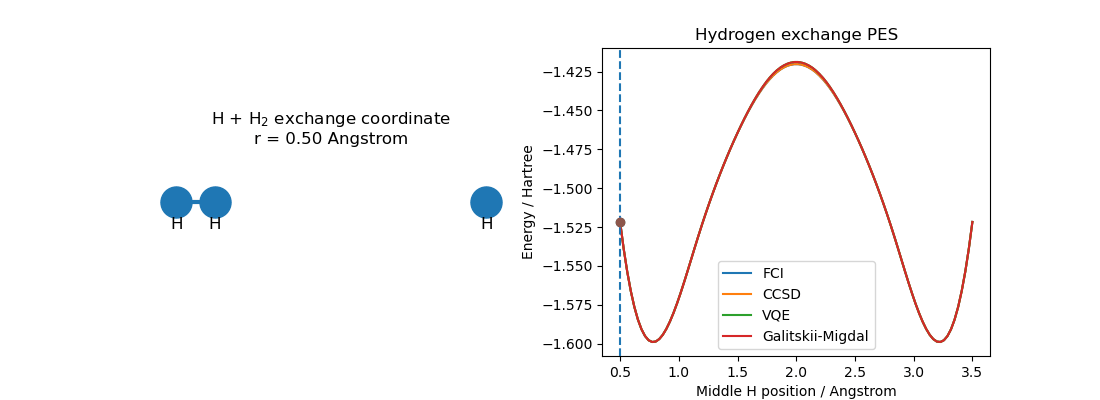

In [15]:
def animate_h3_pes(
    r,
    fci_arr,
    ccsd_arr,
    vqe_arr,
    gm_arr,
    filename="h3_exchange_pes.gif",
    fps=2,
):
    r = np.asarray(r)
    fci_arr = np.asarray(fci_arr)
    ccsd_arr = np.asarray(ccsd_arr)
    vqe_arr = np.asarray(vqe_arr)
    gm_arr = np.asarray(gm_arr)

    fig, (ax_geom, ax_pes) = plt.subplots(
        1, 2, figsize=(11, 4)
    )

    # ---------- geometry panel ----------
    ax_geom.set_xlim(-0.5, 4.5)
    ax_geom.set_ylim(-1.0, 1.0)
    ax_geom.set_aspect("equal")
    ax_geom.axis("off")

    atoms = ax_geom.scatter([], [], s=500)
    bond_left, = ax_geom.plot([], [], lw=3)
    bond_right, = ax_geom.plot([], [], lw=3)
    geom_title = ax_geom.text(
        2.0, 0.75, "", ha="center", fontsize=12
    )

    labels = [
        ax_geom.text(0, 0, "H", ha="center", fontsize=12)
        for _ in range(3)
    ]

    # ---------- PES panel ----------
    ax_pes.plot(r, fci_arr, label="FCI")
    ax_pes.plot(r, ccsd_arr, label="CCSD")
    ax_pes.plot(r, vqe_arr, label="VQE")
    ax_pes.plot(r, gm_arr, label="Galitskii-Migdal")

    marker_line = ax_pes.axvline(r[0], linestyle="--")
    fci_point, = ax_pes.plot([], [], "o")
    vqe_point, = ax_pes.plot([], [], "o")

    ax_pes.set_xlabel("Middle H position / Angstrom")
    ax_pes.set_ylabel("Energy / Hartree")
    ax_pes.set_title("Hydrogen exchange PES")
    ax_pes.legend()

    def update(i):
        x1 = 0.0
        x2 = r[i]
        x3 = 4.0

        xs = np.array([x1, x2, x3])
        ys = np.zeros(3)

        atoms.set_offsets(np.c_[xs, ys])

        for lab, x in zip(labels, xs):
            lab.set_position((x, -0.35))

        # crude bond indicator
        if abs(x2 - x1) < 1.8:
            bond_left.set_data([x1, x2], [0, 0])
        else:
            bond_left.set_data([], [])

        if abs(x3 - x2) < 1.8:
            bond_right.set_data([x2, x3], [0, 0])
        else:
            bond_right.set_data([], [])

        geom_title.set_text(
            f"H + H$_2$ exchange coordinate\nr = {r[i]:.2f} Angstrom"
        )

        marker_line.set_xdata([r[i], r[i]])
        fci_point.set_data([r[i]], [fci_arr[i]])
        vqe_point.set_data([r[i]], [vqe_arr[i]])

        return (
            atoms,
            bond_left,
            bond_right,
            geom_title,
            marker_line,
            fci_point,
            vqe_point,
            *labels,
        )

    anim = FuncAnimation(
        fig,
        update,
        frames=len(r),
        interval=1000 / fps,
        blit=True,
    )

    anim.save(filename, writer=PillowWriter(fps=fps))
    plt.close(fig)

    return filename


r_smooth = np.linspace(r.min(), r.max(), 100)
fci_smooth = interp1d(r, fci_arr, kind="cubic")(r_smooth)
ccsd_smooth = interp1d(r, ccsd_arr, kind="cubic")(r_smooth)
vqe_smooth = interp1d(r, vqe_arr, kind="cubic")(r_smooth)
gm_smooth = interp1d(r, gm_arr, kind="cubic")(r_smooth)

gif_path = animate_h3_pes(
    r_smooth,
    fci_smooth,
    ccsd_smooth,
    vqe_smooth,
    gm_smooth,
    filename="h3_exchange_pes_smooth.gif",
    fps=15,
)

display(Image(filename=gif_path))

### 5) Statevector simulation of Hydrogen attack of Boron Nitrate

In [16]:
# ---------- Animation 2: BN + H2 approach ----------
def make_bn_h2_attack_gif(filename="./bn_h2_attack.gif"):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.set_xlim(-4.5, 2.2)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.axis("off")
    
    # BN fixed, H2 approaches B side
    x_B = 0.0
    x_N = 1.28
    hh = 0.74
    h2_start = -4.0
    h2_end = -1.25
    h2_positions = np.linspace(h2_start, h2_end, 60)
    
    points = ax.scatter([], [], s=500)
    labels = []
    bonds = []
    title = ax.text(-1.1, 0.95, "", ha="center", fontsize=13)
    
    def init():
        points.set_offsets(np.empty((0, 2)))
        return [points, title]
    
    def update(frame):
        nonlocal labels, bonds
        for t in labels:
            t.remove()
        for b in bonds:
            b.remove()
        labels = []
        bonds = []
        
        x_H1 = h2_positions[frame]
        x_H2 = x_H1 - hh
        
        xs = np.array([x_B, x_N, x_H1, x_H2])
        ys = np.array([0.0, 0.0, 0.0, 0.0])
        points.set_offsets(np.c_[xs, ys])
        
        # BN bond
        bonds.append(ax.plot([x_B, x_N], [0, 0], lw=4)[0])
        # H-H bond
        bonds.append(ax.plot([x_H1, x_H2], [0, 0], lw=3)[0])
        # weak interaction / attack line when close
        if abs(x_H1 - x_B) < 2.0:
            bonds.append(ax.plot([x_H1, x_B], [0, 0], lw=2, linestyle="--")[0])
        
        for x, lab in zip(xs, ["B", "N", "H", "H"]):
            labels.append(ax.text(x, -0.48, lab, ha="center", fontsize=12))
        
        title.set_text(r"BN $\cdots$ H$_2$ approach / hydrogen attack coordinate")
        return [points, title] + labels + bonds
    
    anim = FuncAnimation(fig, update, frames=len(h2_positions), init_func=init, blit=True)
    anim.save(filename, writer=PillowWriter(fps=12))
    plt.close(fig)
    return filename

bn_h2_path = make_bn_h2_attack_gif()
bn_h2_path

'./bn_h2_attack.gif'

In [1]:
def build_bnh_molecule(
    basis="sto-3g",
    bn_bond=1.281,
    h_distance=1.5,
):
    """
    Construct neutral doublet BNH.

    Geometry:
        B at z = 0
        N at z = +bn_bond
        H at z = -h_distance
    """
    mol = gto.Mole()

    mol.atom = f"""
    B   0.000000   0.000000    0.000000
    N   0.000000   0.000000    {bn_bond}
    H   0.000000   0.000000   {-h_distance}
    """

    mol.basis = basis
    mol.charge = 0
    mol.spin = 1
    mol.unit = "Angstrom"
    mol.verbose = 0
    mol.build()

    return mol

def run_rohf(
    mol,
    conv_tol=1e-10,
    max_cycle=200,
):
    """
    Run ROHF with a Newton fallback.
    """
    mf = scf.ROHF(mol)
    mf.conv_tol = conv_tol
    mf.max_cycle = max_cycle
    mf.kernel()

    if not mf.converged:
        print("Standard ROHF failed; trying Newton ROHF.")

        mf = mf.newton()
        mf.conv_tol = conv_tol
        mf.max_cycle = 100
        mf.kernel()

    if not mf.converged:
        raise RuntimeError("ROHF did not converge.")

    return mf

mol = build_bnh_molecule() 
mf = run_rohf(mol)

engine = CASSpectralMoments(
    mf=mf,
    ncas=3,
    nelecas=(2, 1),
)

exact = engine.run_exact_casci()

print(
    "Exact CASCI:",
    exact["casci_energy"],
)

vqe = engine.run_vqe(
    max_steps=500,
    stepsize=0.05,
    conv_tol=1e-8,
    verbose=True,
)

print(
    "VQE:",
    vqe["vqe_total_energy"],
)

print(
    "VQE - CASCI:",
    vqe["vqe_total_energy"]
    - exact["casci_energy"],
)

moments = engine.compute_moments(
    theta=vqe["vqe_params"],
    nmom=10,
)

checks = engine.validate_moments(
    moments["hole_moments"],
    moments["particle_moments"],
)

print(checks)

gm = engine.galitskii_migdal_energy(
    moments["hole_moments"]
)

print(
    "Galitskii-Migdal:",
    gm["total"],
)

NameError: name 'gto' is not defined

In [4]:
h_distances = np.array([
    0.8,
    0.9,
    1.0,
    1.1,
    1.2,
    1.3,
    1.4,
    1.5,
    1.6,
    1.7,
    1.8,
    1.9,
    2.0,
    2.1,
    2.2,
    2.3,
    2.4,
    2.5,
    2.6,
    2.7,
])


casci_arr = []
vqe_arr = []
gm_arr = []

vqe_casci_error_arr = []
gm_vqe_error_arr = []
sum_rule_error_arr = []

all_results = []


for r in h_distances:

    print("\n" + "=" * 80)
    print(f"H-B distance = {r:.2f} Å")
    print("=" * 80)

    # --------------------------------------------------
    # 1. Build molecule and ROHF reference
    # --------------------------------------------------
    mol = build_bnh_molecule(
        h_distance=r,
    )

    try:
        mf = run_rohf(mol)

    except RuntimeError as err:
        print(
            f"Skipping R = {r:.2f} Å "
            f"because ROHF failed: {err}"
        )

        casci_arr.append(np.nan)
        vqe_arr.append(np.nan)
        gm_arr.append(np.nan)

        vqe_casci_error_arr.append(np.nan)
        gm_vqe_error_arr.append(np.nan)
        sum_rule_error_arr.append(np.nan)

        all_results.append(None)

        continue

    # --------------------------------------------------
    # 2. Construct CAS(3e,3o) engine
    # --------------------------------------------------
    engine = CASSpectralMoments(
        mf=mf,
        ncas=3,
        nelecas=(2, 1),
    )

    # --------------------------------------------------
    # 3. Exact CASCI
    # --------------------------------------------------
    exact = engine.run_exact_casci()

    e_casci = exact[
        "casci_energy"
    ]

    # --------------------------------------------------
    # 4. VQE
    # --------------------------------------------------
    vqe = engine.run_vqe(
        max_steps=500,
        stepsize=0.05,
        conv_tol=1e-8,
        verbose=False,
    )

    e_vqe = vqe[
        "vqe_total_energy"
    ]

    # --------------------------------------------------
    # 5. Spectral moments
    # --------------------------------------------------
    moments = engine.compute_moments(
        theta=vqe["vqe_params"],
        nmom=10,
    )

    # --------------------------------------------------
    # 6. Moment diagnostics
    # --------------------------------------------------
    checks = engine.validate_moments(
        moments["hole_moments"],
        moments["particle_moments"],
    )

    # --------------------------------------------------
    # 7. Galitskii-Migdal energy
    # --------------------------------------------------
    gm = engine.galitskii_migdal_energy(
        moments["hole_moments"]
    )

    e_gm = gm[
        "total"
    ]

    # --------------------------------------------------
    # 8. Errors
    # --------------------------------------------------
    vqe_casci_error = (
        e_vqe - e_casci
    )

    gm_vqe_error = (
        e_gm - e_vqe
    )

    sum_rule_error = checks[
        "zeroth_sum_rule_error"
    ]

    # --------------------------------------------------
    # 9. Store
    # --------------------------------------------------
    casci_arr.append(
        e_casci
    )

    vqe_arr.append(
        e_vqe
    )

    gm_arr.append(
        e_gm
    )

    vqe_casci_error_arr.append(
        vqe_casci_error
    )

    gm_vqe_error_arr.append(
        gm_vqe_error
    )

    sum_rule_error_arr.append(
        sum_rule_error
    )

    all_results.append({
        "distance": r,
        "mol": mol,
        "mf": mf,
        "engine": engine,
        "exact": exact,
        "vqe": vqe,
        "moments": moments,
        "checks": checks,
        "gm": gm,
    })

    # --------------------------------------------------
    # 10. Print summary
    # --------------------------------------------------
    print(
        f"CASCI = {e_casci:.10f} Ha"
    )

    print(
        f"VQE   = {e_vqe:.10f} Ha"
    )

    print(
        f"GM    = {e_gm:.10f} Ha"
    )

    print(
        f"VQE - CASCI = "
        f"{vqe_casci_error:+.6e} Ha"
    )

    print(
        f"GM - VQE    = "
        f"{gm_vqe_error:+.6e} Ha"
    )

    print(
        f"T0 sum-rule error = "
        f"{sum_rule_error:.6e}")


H-B distance = 0.80 Å
CASCI = -78.4767835660 Ha
VQE   = -78.4767772583 Ha
GM    = -78.4767772583 Ha
VQE - CASCI = +6.307681e-06 Ha
GM - VQE    = +1.094236e-12 Ha
T0 sum-rule error = 9.512273e-14

H-B distance = 0.90 Å
CASCI = -78.5628453095 Ha
VQE   = -78.5628393877 Ha
GM    = -78.5628393877 Ha
VQE - CASCI = +5.921759e-06 Ha
GM - VQE    = +1.222134e-12 Ha
T0 sum-rule error = 9.768650e-14

H-B distance = 1.00 Å
CASCI = -78.6064404400 Ha
VQE   = -78.6064348512 Ha
GM    = -78.6064348512 Ha
VQE - CASCI = +5.588751e-06 Ha
GM - VQE    = +1.222134e-12 Ha
T0 sum-rule error = 9.999406e-14

H-B distance = 1.10 Å
CASCI = -78.6230010762 Ha
VQE   = -78.6229957599 Ha
GM    = -78.6229957599 Ha
VQE - CASCI = +5.316351e-06 Ha
GM - VQE    = +1.165290e-12 Ha
T0 sum-rule error = 8.973844e-14

H-B distance = 1.20 Å
CASCI = -78.6222130834 Ha
VQE   = -78.6222079813 Ha
GM    = -78.6222079813 Ha
VQE - CASCI = +5.102106e-06 Ha
GM - VQE    = +9.521273e-13 Ha
T0 sum-rule error = 9.268680e-14

H-B distance = 1.30

In [7]:
casci_arr = np.asarray(
    casci_arr,
    dtype=float,
)

vqe_arr = np.asarray(
    vqe_arr,
    dtype=float,
)

gm_arr = np.asarray(
    gm_arr,
    dtype=float,
)

vqe_casci_error_arr = np.asarray(
    vqe_casci_error_arr,
    dtype=float,
)

gm_vqe_error_arr = np.asarray(
    gm_vqe_error_arr,
    dtype=float,
)

sum_rule_error_arr = np.asarray(
    sum_rule_error_arr,
    dtype=float,
)

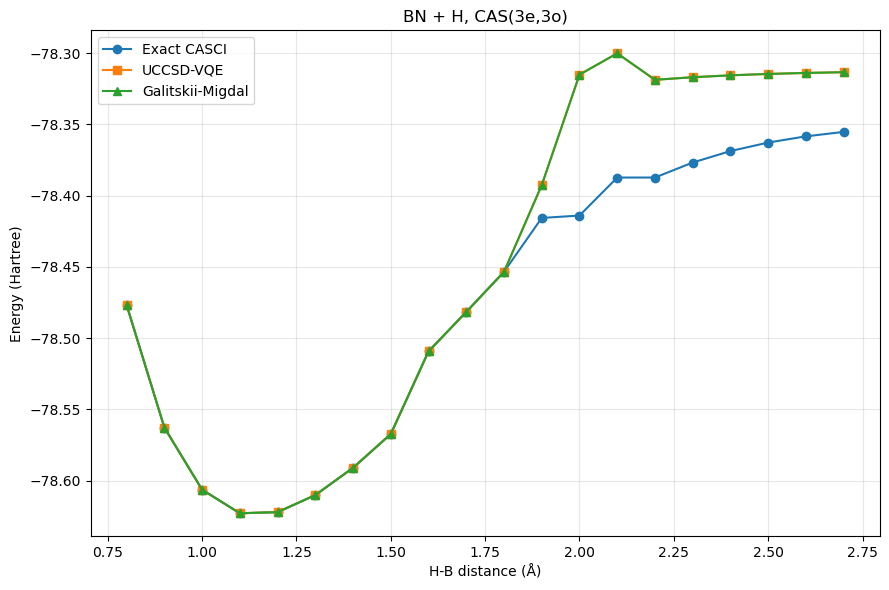

In [8]:
plt.figure(figsize=(9, 6))

plt.plot(
    h_distances,
    casci_arr,
    marker="o",
    label="Exact CASCI",
)

plt.plot(
    h_distances,
    vqe_arr,
    marker="s",
    label="UCCSD-VQE",
)

plt.plot(
    h_distances,
    gm_arr,
    marker="^",
    label="Galitskii-Migdal",
)

plt.xlabel(
    "H-B distance (Å)"
)

plt.ylabel(
    "Energy (Hartree)"
)

plt.title(
    "BN + H, CAS(3e,3o)"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

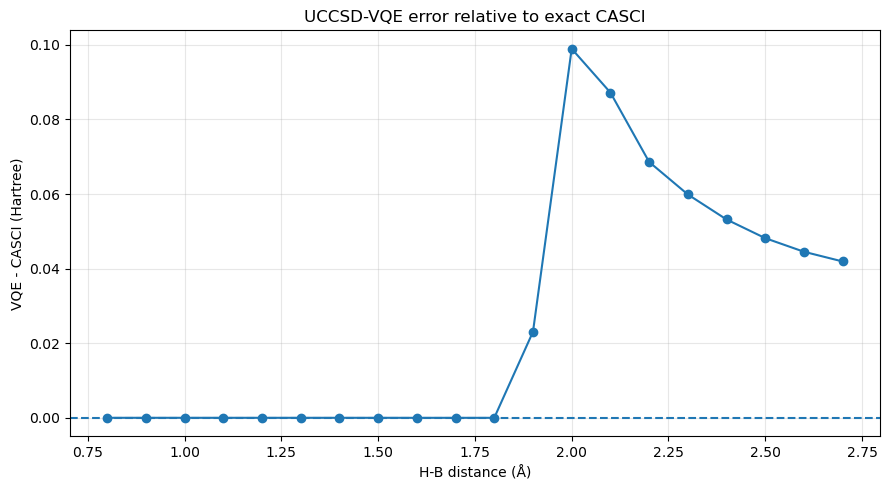

In [9]:
plt.figure(figsize=(9, 5))

plt.plot(
    h_distances,
    vqe_casci_error_arr,
    marker="o",
)

plt.axhline(
    0.0,
    linestyle="--",
)

plt.xlabel(
    "H-B distance (Å)"
)

plt.ylabel(
    "VQE - CASCI (Hartree)"
)

plt.title(
    "UCCSD-VQE error relative to exact CASCI"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

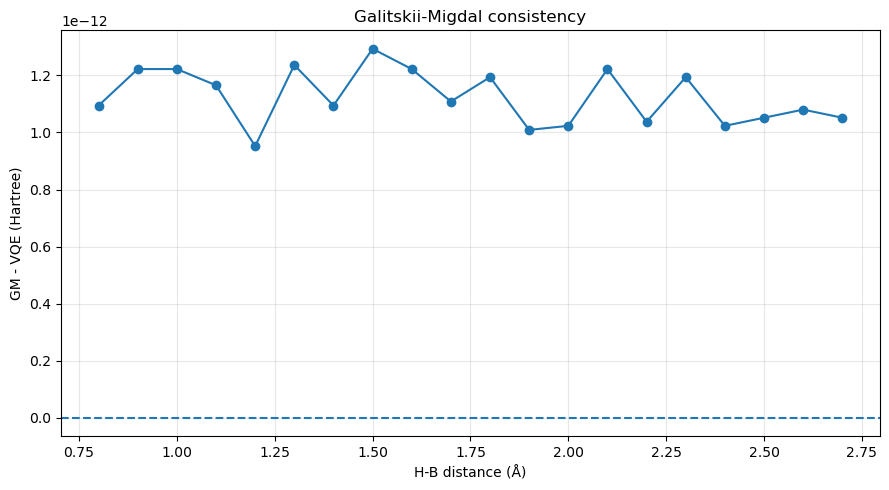

In [10]:
plt.figure(figsize=(9, 5))

plt.plot(
    h_distances,
    gm_vqe_error_arr,
    marker="o",
)

plt.axhline(
    0.0,
    linestyle="--",
)

plt.xlabel(
    "H-B distance (Å)"
)

plt.ylabel(
    "GM - VQE (Hartree)"
)

plt.title(
    "Galitskii-Migdal consistency"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

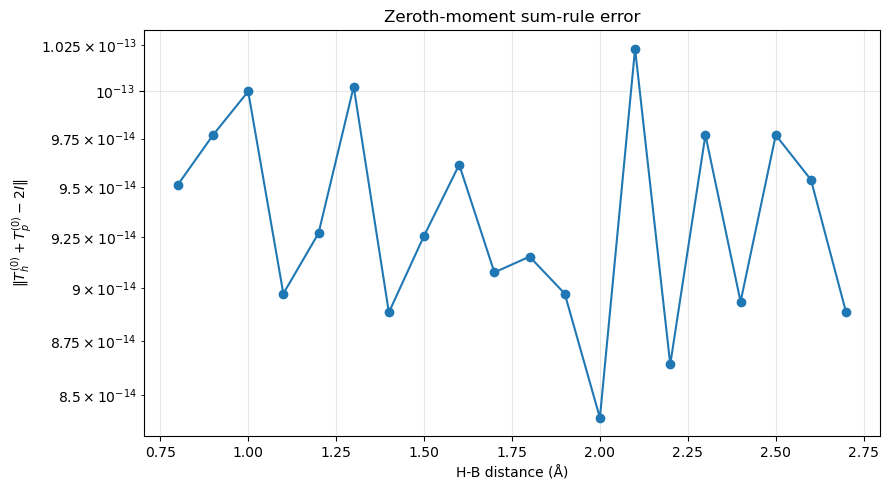

In [11]:
plt.figure(figsize=(9, 5))

plt.semilogy(
    h_distances,
    sum_rule_error_arr,
    marker="o",
)

plt.xlabel(
    "H-B distance (Å)"
)

plt.ylabel(
    r"$\|T_h^{(0)} + T_p^{(0)} - 2I\|$"
)

plt.title(
    "Zeroth-moment sum-rule error"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
## test code 

def build_bnh_molecule(
    basis="sto-3g",
    bn_bond=1.281,
    h_distance=1.5,
):
    """
    Construct neutral doublet BNH.

    Geometry:
        B at z = 0
        N at z = +bn_bond
        H at z = -h_distance
    """
    mol = gto.Mole()

    mol.atom = f"""
    B   0.000000   0.000000    0.000000
    N   0.000000   0.000000    {bn_bond}
    H   0.000000   0.000000   {-h_distance}
    """

    mol.basis = basis
    mol.charge = 0
    mol.spin = 1
    mol.unit = "Angstrom"
    mol.verbose = 0
    mol.build()

    return mol

def run_rohf(
    mol,
    conv_tol=1e-10,
    max_cycle=200,
):
    """
    Run ROHF with a Newton fallback.
    """
    mf = scf.ROHF(mol)
    mf.conv_tol = conv_tol
    mf.max_cycle = max_cycle
    mf.kernel()

    if not mf.converged:
        print("Standard ROHF failed; trying Newton ROHF.")

        mf = mf.newton()
        mf.conv_tol = conv_tol
        mf.max_cycle = 100
        mf.kernel()

    if not mf.converged:
        raise RuntimeError("ROHF did not converge.")

    return mf

mol = build_bnh_molecule(h_distance=1.24) 
mf = run_rohf(mol)


In [6]:
engine = CASSpectralMoments(
    mf=mf,
    ncas=3,
    nelecas=(2, 1),
)

exact = engine.run_exact_casci()

print(
    "Exact CASCI:",
    exact["casci_energy"],
)

vqe = engine.run_vqe(
    max_steps=500,
    stepsize=0.05,
    conv_tol=1e-8,
    verbose=True,
)

print(
    "VQE:",
    vqe["vqe_total_energy"],
)

print(
    "VQE - CASCI:",
    vqe["vqe_total_energy"]
    - exact["casci_energy"],
)

moments = engine.compute_moments(
    theta=vqe["vqe_params"],
    nmom=10,
)

Exact CASCI: -78.61850325981077
Step    0 | E = -78.587098775815 Ha
Step   10 | E = -78.597172960099 Ha
Step   20 | E = -78.603951848934 Ha
Step   30 | E = -78.608509658611 Ha
Step   40 | E = -78.611581684952 Ha
Step   50 | E = -78.613662158169 Ha
Step   60 | E = -78.615080135387 Ha
Step   70 | E = -78.616053883546 Ha
Step   80 | E = -78.616728198926 Ha
Step   90 | E = -78.617199400817 Ha
Step  100 | E = -78.617531849546 Ha
Step  110 | E = -78.617768794107 Ha
Step  120 | E = -78.617939483245 Ha
Step  130 | E = -78.618063832991 Ha
Step  140 | E = -78.618155500627 Ha
Step  150 | E = -78.618223918855 Ha
Step  160 | E = -78.618275649595 Ha
Step  170 | E = -78.618315290666 Ha
Step  180 | E = -78.618346087027 Ha
Step  190 | E = -78.618370345631 Ha
Step  200 | E = -78.618389718839 Ha
Step  210 | E = -78.618405399311 Ha
Step  220 | E = -78.618418254864 Ha
Step  230 | E = -78.618428922340 Ha
Step  240 | E = -78.618437873328 Ha
Step  250 | E = -78.618445460429 Ha
Step  260 | E = -78.618451949996

In [7]:
print(
    "Hole moments:\n",
    moments["hole_moments"],
)

Hole moments:
 [[[ 1.91720490e+00+0.j -7.39106838e-17+0.j  4.91737514e-02+0.j]
  [-7.39106838e-17+0.j  1.00000000e+00+0.j  2.34148824e-16+0.j]
  [ 4.91737514e-02+0.j  2.34148824e-16+0.j  8.27951025e-02+0.j]]

 [[-7.46863520e-01+0.j  3.69869737e-17+0.j  2.18355050e-02+0.j]
  [ 3.69869737e-17+0.j -4.42363231e-01+0.j -1.04899853e-16+0.j]
  [ 2.18355050e-02+0.j -1.04899853e-16+0.j -6.11717074e-02+0.j]]

 [[ 3.11698862e-01+0.j -2.89706920e-17+0.j -3.94389100e-02+0.j]
  [-2.89706920e-17+0.j  2.07738873e-01+0.j  5.09584929e-17+0.j]
  [-3.94389100e-02+0.j  5.09584929e-17+0.j  4.74929303e-02+0.j]]

 [[-1.45380811e-01+0.j  3.01620734e-17+0.j  3.96438598e-02+0.j]
  [ 3.01620734e-17+0.j -1.08408212e-01+0.j -2.93622524e-17+0.j]
  [ 3.96438598e-02+0.j -2.93622524e-17+0.j -3.77621376e-02+0.j]]

 [[ 7.85090363e-02+0.j -3.53907481e-17+0.j -3.48578935e-02+0.j]
  [-3.53907481e-17+0.j  6.65555167e-02+0.j  2.23457623e-17+0.j]
  [-3.48578935e-02+0.j  2.23457623e-17+0.j  3.03544105e-02+0.j]]

 [[-4.91696651e

In [ ]:
Hole moment
[[[ 1.91675695e+00 -4.76994778e-15  4.92956425e-02]
  [-4.76994778e-15  1.00000000e+00 -1.16436145e-15]
  [ 4.92956425e-02 -1.16436145e-15  8.32430485e-02]]

 [[-7.46809869e-01  1.54163995e-15  2.19586813e-02]
  [ 1.51972584e-15 -4.42499835e-01  2.19249782e-16]
  [ 2.19586813e-02  2.17738327e-16 -6.13480379e-02]]

 [[ 3.11793908e-01 -5.14973095e-16 -3.95777982e-02]
  [-4.96449396e-16  2.07892949e-01  9.80447206e-17]
  [-3.95777982e-02  1.00382849e-16  4.75723519e-02]]

 [[-1.45523929e-01  1.80590306e-16  3.97567632e-02]
  [ 1.68219091e-16 -1.08540296e-01 -1.82240429e-16]
  [ 3.97567632e-02 -1.85004579e-16 -3.78058582e-02]]

 [[ 7.86596031e-02 -5.34485066e-17 -3.49461090e-02]
  [-4.54103781e-17  6.66549747e-02  1.82743282e-16]
  [-3.49461090e-02  1.85694342e-16  3.03839195e-02]]

 [[-4.93119484e-02 -1.91314964e-17  2.93043165e-02]
  [-2.47241234e-17 -5.01147269e-02 -1.55524945e-16]
  [ 2.93043165e-02 -1.58518575e-16 -2.45432991e-02]]

 [[ 3.46557458e-02  8.61126852e-17 -2.41175146e-02]
  [ 9.04844199e-17  4.59708084e-02  1.20693921e-16]
  [-2.41175146e-02  1.23643949e-16  1.98715588e-02]]

 [[-2.61451583e-02 -1.67095437e-16  1.96959058e-02]
  [-1.70948835e-16 -4.95492849e-02 -8.43905209e-17]
  [ 1.96959058e-02 -8.72486799e-17 -1.61070718e-02]]

 [[ 2.04936107e-02  2.76503384e-16 -1.60337463e-02]
  [ 2.80253989e-16  6.00554045e-02  4.70504142e-17]
  [-1.60337463e-02  4.97952070e-17  1.30634791e-02]]

 [[-1.63742568e-02 -4.32317623e-16  1.30360967e-02]
  [-4.36268385e-16 -7.89516432e-02 -6.36576074e-18]
  [ 1.30360967e-02 -8.99684357e-18 -1.05988824e-02]]

 [[ 1.32050714e-02  6.60912911e-16 -1.05943350e-02]
  [ 6.65370642e-16  1.09602706e-01 -4.19150835e-17]
  [-1.05943350e-02 -3.93786728e-17  8.60157299e-03]]]